# **Homework 12 - Reinforcement Learning**

若有任何問題，歡迎來信至助教信箱 ntu-ml-2021spring-ta@googlegroups.com



首先安裝必要的 PyPI 套件。
Gymnasium 是 OpenAI gym 的官方继任者，是一套用來開發與比較 Reinforcement Learning 演算法的工具包（toolkit）。
其餘套件（matplotlib、tqdm 等）是為了在 Notebook 中繪圖與顯示進度所需要的套件。


In [147]:
!pip install gymnasium[box2d] torch tqdm numpy matplotlib ipython


zsh:1: no matches found: gymnasium[box2d]


接下來，引入所有必要的套件（使用 Gymnasium 作為強化學習環境）。


In [148]:
import time
import os
import random
import gymnasium as gym

import matplotlib.pyplot as plt
from IPython import display

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
from tqdm.notebook import tqdm


# 請不要更改 random seed !!!!
# 不然在judgeboi上 你的成績不會被reproduce !!!!

In [149]:
seed = 543 # Do not change this
def fix(env, seed):
  env.action_space.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  np.random.seed(seed)
  random.seed(seed)
  torch.use_deterministic_algorithms(True)  # 取代已移除的 torch.set_deterministic
  torch.backends.cudnn.benchmark = False
  torch.backends.cudnn.deterministic = True
  env.reset(seed=seed)  # Gymnasium 已移除 env.seed，改用 reset(seed=...) 设置环境随机种子


最後，使用 Gymnasium 建立一個 [Lunar Lander](https://gym.openai.com/envs/LunarLander-v2/) 環境。


In [150]:
env = gym.make('LunarLander-v3', render_mode='rgb_array')

fix(env, seed)


In [151]:
start = time.time()

In [152]:
!pip freeze

accelerate==1.1.1
aiobotocore @ file:///private/var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_b2htsn1rgl/croot/aiobotocore_1738237874912/work
aiofiles==25.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aioitertools @ file:///tmp/build/80754af9/aioitertools_1607109665762/work
aiosignal==1.4.0
alabaster @ file:///Users/builder/cbouss/perseverance-python-buildout/croot/alabaster_1728591579756/work
aliyun-python-sdk-alidns==3.0.7
aliyun-python-sdk-core==2.16.0
aliyun-python-sdk-kms==2.16.5
altair @ file:///private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_7ew3pavrjt/croot/altair_1743016738697/work
amqp==5.3.1
anaconda-anon-usage @ file:///private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_degjgm8ut1/croot/anaconda-anon-usage_1749054786234/work
anaconda-auth @ file:///private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_c9m1keso7m/croot/anaconda-cloud-auth-split_1747863789573/work
anaconda-catalogs @ file:///private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/

## 什麼是 Lunar Lander？

“LunarLander-v2” 這個環境是在模擬登月小艇降落在月球表面時的情形。
這個任務的目標是讓登月小艇「安全地」降落在兩個黃色旗幟間的平地上。
> Landing pad is always at coordinates (0,0).
> Coordinates are the first two numbers in state vector.

![](https://gym.openai.com/assets/docs/aeloop-138c89d44114492fd02822303e6b4b07213010bb14ca5856d2d49d6b62d88e53.svg)

所謂的「環境」其實同時包括了 agent 和 environment。
我們利用 `step()` 這個函式讓 agent 行動，而後函式便會回傳 environment 給予的 observation/state（以下這兩個名詞代表同樣的意思）和 reward。

### Observation / State

首先，我們可以看看 environment 回傳給 agent 的 observation 究竟是長什麼樣子的資料：

In [153]:
print(env.observation_space)

Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)


`Box(8,)` 說明我們會拿到 8 維的向量作為 observation，其中包含：垂直及水平座標、速度、角度、加速度等等，這部分我們就不細說。

### Action

而在 agent 得到 observation 和 reward 以後，能夠採取的動作有：

In [154]:
print(env.action_space)

Discrete(4)


`Discrete(4)` 說明 agent 可以採取四種離散的行動：
- 0 代表不採取任何行動
- 2 代表主引擎向下噴射
- 1, 3 則是向左右噴射

接下來，我們嘗試讓 agent 與 environment 互動。
在進行任何操作前，建議先呼叫 `reset()` 函式讓整個「環境」重置。
而這個函式同時會回傳「環境」最初始的狀態。

In [155]:
initial_state, _ = env.reset()
print(initial_state)


[ 0.00708485  1.4177319   0.7175924   0.30272725 -0.00820266 -0.16254534
  0.          0.        ]


接著，我們試著從 agent 的四種行動空間中，隨機採取一個行動

In [156]:
random_action = env.action_space.sample()
print(random_action)

3


再利用 `step()` 函式讓 agent 根據我們隨機抽樣出來的 `random_action` 動作。
而這個函式會回傳四項資訊：
- observation / state
- reward
- 完成與否
- 其餘資訊

In [157]:
observation, reward, terminated, truncated, info = env.step(random_action)
done = terminated or truncated


第一項資訊 `observation` 即為 agent 採取行動之後，agent 對於環境的 observation 或者說環境的 state 為何。
而第三項資訊 `done` 則是 `True` 或 `False` 的布林值，當登月小艇成功著陸或是不幸墜毀時，代表這個回合（episode）也就跟著結束了，此時 `step()` 函式便會回傳 `done = True`，而在那之前，`done` 則保持 `False`。

In [158]:
print(done)

False


### Reward

而「環境」給予的 reward 大致是這樣計算：
- 小艇墜毀得到 -100 分
- 小艇在黃旗幟之間成功著地則得 100~140 分
- 噴射主引擎（向下噴火）每次 -0.3 分
- 小艇最終完全靜止則再得 100 分
- 小艇每隻腳碰觸地面 +10 分

> Reward for moving from the top of the screen to landing pad and zero speed is about 100..140 points.
> If lander moves away from landing pad it loses reward back.
> Episode finishes if the lander crashes or comes to rest, receiving additional -100 or +100 points.
> Each leg ground contact is +10.
> Firing main engine is -0.3 points each frame.


In [159]:
print(reward) # after doing a random action (0), the immediate reward is stored in this 

-1.6296973630518596


### Random Agent

最後，在進入實做之前，我們就來看看這樣一個 random agent 能否成功登陸月球：

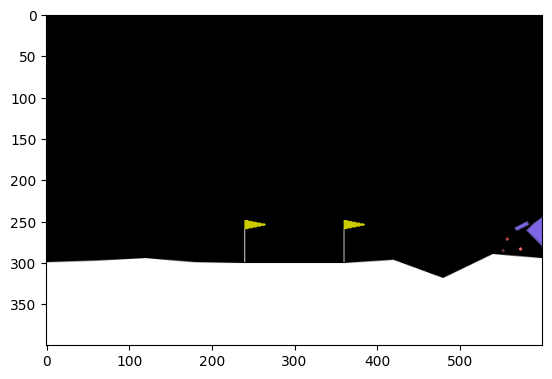

In [160]:

state, _ = env.reset()

img = plt.imshow(env.render())

done = False
while not done:
    action = env.action_space.sample()
    observation, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    img.set_data(env.render())
    display.display(plt.gcf())
    display.clear_output(wait=True)

## DQN (Deep Q-Network)

現在我們搭建一個簡單的 Q 網路（Q-Network）。
我們預設模型的輸入是 8-dim 的 observation，輸出則是離散的四個動作各自對應的 Q 值（共 4 個，不接 softmax）。


In [161]:
class DQNNetwork(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 4)

    def forward(self, state):
        hid = torch.relu(self.fc1(state))
        hid = torch.relu(self.fc2(hid))
        return self.fc3(hid)  # 4 個動作的 Q 值，不接 softmax


from collections import deque

class ReplayBuffer:
    """經驗回放緩衝區：儲存 (s, a, r, s', done) 轉換，訓練時隨機抽樣以打斷相關性。"""

    def __init__(self, capacity=20000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return (np.array(state, dtype=np.float32),
                np.array(action, dtype=np.int64),
                np.array(reward, dtype=np.float32),
                np.array(next_state, dtype=np.float32),
                np.array(done, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)


再來，搭建一個 DQN agent，搭配上方的 Q 網路來選擇動作並更新參數。
這個 agent 具備以下機制：
- `ReplayBuffer`：把與環境互動的經驗存起來，訓練時隨機抽樣（經驗回放）。
- `target` 目標網路：一份定期同步的 Q 網路副本，用來計算穩定的 TD 目標，降低訓練震盪。
- `act()`：訓練時用 ε-greedy 探索；`sample()`：測試時走貪心（取 Q 值最大的動作）。
- `learn()`：用一筆批次的經驗，以 Huber 損失最小化 TD 誤差來更新 Q 網路。


In [162]:
class DQNAgent():

    def __init__(self, network, lr=1e-3, gamma=0.99):
        self.network = network
        self.target = DQNNetwork()  # 目標網路
        self.target.load_state_dict(network.state_dict())
        self.target.eval()
        self.optimizer = optim.Adam(network.parameters(), lr=lr)
        self.gamma = gamma
        self.criterion = nn.SmoothL1Loss()  # Huber loss，比 MSE 更穩健

    def act(self, state, epsilon):
        """ε-greedy：以 epsilon 機率隨機探索，否則取 Q 值最大的動作。"""
        if random.random() < epsilon:
            return random.randrange(4)
        state_t = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q = self.network(state_t)
        return int(q.argmax(dim=1).item())

    def sample(self, state):
        """測試時（network 處於 eval 模式）走貪心策略。"""
        state_t = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q = self.network(state_t)
        return int(q.argmax(dim=1).item()), None

    def learn(self, batch):
        states, actions, rewards, next_states, dones = batch
        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(next_states)
        dones = torch.FloatTensor(dones).unsqueeze(1)

        q_values = self.network(states).gather(1, actions)            # Q(s, a)
        with torch.no_grad():
            next_q = self.target(next_states).max(dim=1, keepdim=True)[0]
            target = rewards + self.gamma * next_q * (1.0 - dones)     # TD 目標
        loss = self.criterion(q_values, target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.item()

    def update_target(self):
        self.target.load_state_dict(self.network.state_dict())

    def save(self, PATH):
        torch.save({
            "network": self.network.state_dict(),
            "target": self.target.state_dict(),
            "optimizer": self.optimizer.state_dict(),
        }, PATH)

    def load(self, PATH):
        ckpt = torch.load(PATH, weights_only=False)
        self.network.load_state_dict(ckpt["network"])
        self.target.load_state_dict(ckpt["target"])
        self.optimizer.load_state_dict(ckpt["optimizer"])


最後，建立一個 network 和 agent，就可以開始進行訓練了。

In [163]:
network = DQNNetwork()
agent = DQNAgent(network)


## 訓練 Agent

現在我們開始訓練 agent。DQN 不是像 Policy Gradient 那樣「玩完一整回合作完批次更新」，而是：
1. 讓 agent 與環境互動，把每一筆轉換 `(s, a, r, s', done)` 存入 ReplayBuffer；
2. 當緩衝區樣本足夠，隨機抽一批出來，用目標網路計算 TD 目標 `r + γ·max_a' Q_target(s', a')`，最小化 Q 網路與目標的差距；
3. 定期把 Q 網路的參數同步給目標網路，避免訓練目標漂移。


In [164]:
agent.network.train()  # 訓練前，先確保 network 處在 training 模式
EPISODE_PER_BATCH = 5    # 每輪蒐集的回合数
NUM_BATCH = 2000          # 總共訓練輪數
BATCH_SIZE = 64          # 每次 DQN 更新使用的批次大小
TARGET_UPDATE = 1000     # 每多少步同步一次目標網路
GAMMA = 0.99             # 折扣因子
EPS_START = 1.0          # ε-greedy 初始探索率
EPS_END = 0.05           # ε-greedy 最低探索率
EPS_DECAY = 150000       # 探索率指數衰減步數
MAX_STEPS = 1000         # 單一回合数上限，避免 agent 懸停導致回合過長

buffer = ReplayBuffer(capacity=20000)
avg_total_rewards, avg_final_rewards = [], []

best_avg_total = -float('inf')   # 记录训练过程中最好的平均总回报
best_path = "best_model.pt"     # 最佳模型存档路径

total_steps = 0
prg_bar = tqdm(range(NUM_BATCH))
for batch in prg_bar:

    episode_total_rewards, episode_final_rewards = [], []

    # 蒐集訓練資料
    for episode in range(EPISODE_PER_BATCH):

        state, _ = env.reset()
        total_reward = 0
        done = False
        t = 0
        while not done and t < MAX_STEPS:
            epsilon = EPS_END + (EPS_START - EPS_END) * np.exp(-total_steps / EPS_DECAY)
            action = agent.act(state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            buffer.push(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            total_steps += 1
            t += 1

            # 緩衝區樣本足夠後，做 DQN 更新
            if len(buffer) >= BATCH_SIZE:
                loss = agent.learn(buffer.sample(BATCH_SIZE))

            # 定期同步目標網路
            if total_steps % TARGET_UPDATE == 0:
                agent.update_target()

        episode_total_rewards.append(total_reward)
        episode_final_rewards.append(reward)  # 回合最後一步的即時 reward

    avg_total_reward = sum(episode_total_rewards) / len(episode_total_rewards)
    avg_final_reward = sum(episode_final_rewards) / len(episode_final_rewards)
    avg_total_rewards.append(avg_total_reward)
    avg_final_rewards.append(avg_final_reward)
    prg_bar.set_description(f"Total: {avg_total_reward: 4.1f}, Final: {avg_final_reward: 4.1f}")

    # 若本批次平均总回报创新高，则保存当前（最佳）模型
    if avg_total_reward > best_avg_total:
        best_avg_total = avg_total_reward
        agent.save(best_path)
        print(f"[best] avg_total={avg_total_reward:7.1f} -> saved to {best_path}")


  0%|          | 0/2000 [00:00<?, ?it/s]

[best] avg_total= -275.8 -> saved to best_model.pt
[best] avg_total= -170.1 -> saved to best_model.pt
[best] avg_total= -165.1 -> saved to best_model.pt
[best] avg_total= -146.5 -> saved to best_model.pt
[best] avg_total= -114.0 -> saved to best_model.pt
[best] avg_total= -110.9 -> saved to best_model.pt
[best] avg_total=  -75.7 -> saved to best_model.pt
[best] avg_total=  -57.3 -> saved to best_model.pt
[best] avg_total=  -57.1 -> saved to best_model.pt
[best] avg_total=  -51.0 -> saved to best_model.pt
[best] avg_total=  -49.3 -> saved to best_model.pt
[best] avg_total=  -46.9 -> saved to best_model.pt
[best] avg_total=  -37.3 -> saved to best_model.pt
[best] avg_total=  -27.4 -> saved to best_model.pt
[best] avg_total=  -22.2 -> saved to best_model.pt
[best] avg_total=  -18.8 -> saved to best_model.pt
[best] avg_total=    4.8 -> saved to best_model.pt
[best] avg_total=    5.1 -> saved to best_model.pt
[best] avg_total=    6.7 -> saved to best_model.pt
[best] avg_total=   23.3 -> sav

### 訓練結果

訓練過程中，我們持續記下了 `avg_total_reward`，這個數值代表的是：每次更新 policy network 前，我們讓 agent 玩數個回合（episodes），而這些回合的平均 total rewards 為何。
理論上，若是 agent 一直在進步，則所得到的 `avg_total_reward` 也會持續上升，直至 250 上下。
若將其畫出來則結果如下：

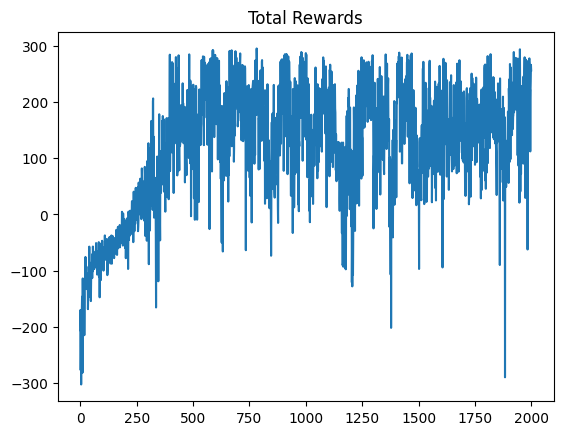

In [165]:
end = time.time()
plt.plot(avg_total_rewards)
plt.title("Total Rewards")
plt.show()

另外，`avg_final_reward` 代表的是多個回合的平均 final rewards，而 final reward 即是 agent 在單一回合中拿到的最後一個 reward。
如果同學們還記得環境給予登月小艇 reward 的方式，便會知道，不論**回合的最後**小艇是不幸墜毀、飛出畫面、或是靜止在地面上，都會受到額外地獎勵或處罰。
也因此，final reward 可被用來觀察 agent 的「著地」是否順利等資訊。

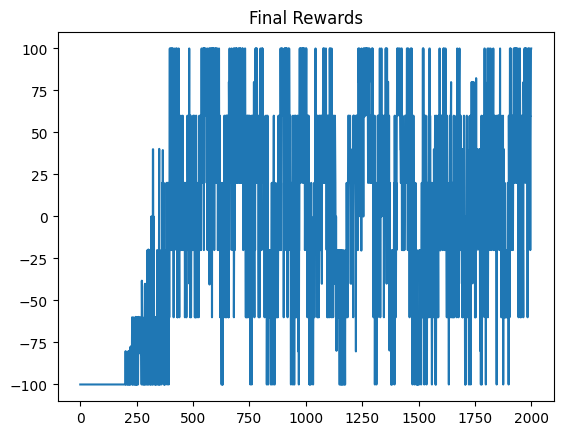

In [166]:
plt.plot(avg_final_rewards)
plt.title("Final Rewards")
plt.show()


訓練時間


In [167]:
print(f"total time is {end-start} sec")

total time is 1413.278067111969 sec


## 測試

304.7120574386234
length of actions is  224
267.13199832094364
length of actions is  194
259.0934549587038
length of actions is  175
266.6427025785152
length of actions is  553
239.60494668417314
length of actions is  365


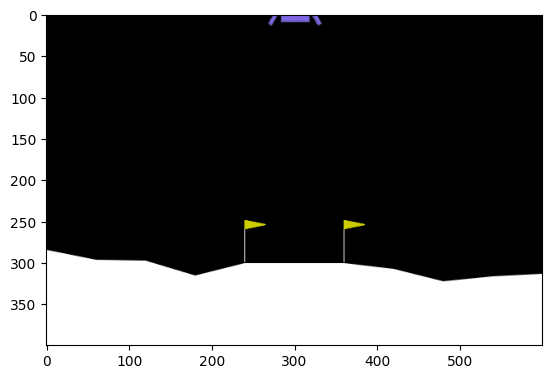

In [168]:
fix(env, seed)
best_path = "best_model.pt"
if os.path.exists(best_path):
    agent.load(best_path)        # 载入训练过程中表现最好的模型，而非最新模型
else:
    print(f"未找到 {best_path}，将直接使用当前（最新）模型进行测试")
agent.network.eval()  # 測試前先將 network 切換為 evaluation 模式
NUM_OF_TEST = 5  # Do not revise it !!!!!
test_total_reward = []
action_list = []
for i in range(NUM_OF_TEST):
    actions = []
    state, _ = env.reset()

    img = plt.imshow(env.render())

    total_reward = 0

    done = False
    while not done:
        action, _ = agent.sample(state)
        actions.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        total_reward += reward

        # img.set_data(env.render())
        # display.display(plt.gcf())
        # display.clear_output(wait=True)
    print(total_reward)
    test_total_reward.append(total_reward)

    action_list.append(actions)  # 儲存你測試的結果
    print("length of actions is ", len(actions))

In [169]:
print(f"Your final reward is : %.2f"%np.mean(test_total_reward))

Your final reward is : 267.44


Action 的分布


In [170]:
distribution = {}
for actions in action_list:
  for action in actions:
    if action not in distribution.keys():
      distribution[action] = 1
    else:
      distribution[action] += 1
print(distribution)

{1: 88, 0: 634, 3: 316, 2: 473}


儲存 Model Testing的結果


In [171]:
PATH = "Action_List_test.npy" # 可以改成你想取的名字或路徑
np.save(PATH, np.array(action_list, dtype=object))  # numpy 2.x 需显式 object dtype 以保存不等长的 action 序列 

### 你要交到JudgeBoi的檔案94這個
儲存結果到本地端 (就是你的電腦裡拉 = = )


In [172]:
print(f"已保存动作列表到本地: {PATH}")


已保存动作列表到本地: Action_List_test.npy


# Server 測試
到時候下面會是我們Server上測試的環境，可以給大家看一下自己的表現如何

Your reward is : 304.71
Your reward is : 267.13
Your reward is : 259.09
Your reward is : 266.64
Your reward is : 239.60


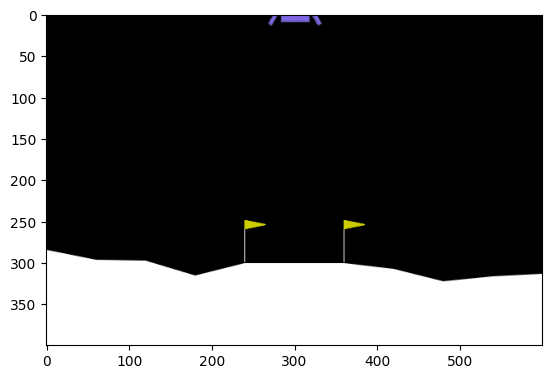

In [173]:
action_list = np.load(PATH,allow_pickle=True) #到時候你上傳的檔案
seed = 543 #到時候測試的seed 請不要更改
fix(env, seed)

agent.network.eval()  # 測試前先將 network 切換為 evaluation 模式

test_total_reward = []
for actions in action_list:
  state, _ = env.reset()
  img = plt.imshow(env.render())

  total_reward = 0

  done = False
  # while not done:
  done_count = 0
  for action in actions:
      # action, _ = agent1.sample(state)
      state, reward, terminated, truncated, _ = env.step(action)
      done = terminated or truncated
      done_count += 1
      total_reward += reward
      if done:
        
        break
    #   img.set_data(env.render())
    #   display.display(plt.gcf())
    #   display.clear_output(wait=True)
  print(f"Your reward is : %.2f"%total_reward)
  test_total_reward.append(total_reward)

# 你的成績

In [174]:
print(f"Your final reward is : %.2f"%np.mean(test_total_reward))

Your final reward is : 267.44


## 參考資料

以下是一些有用的參考資料。
建議同學們實做前，可以先參考第一則連結的上課影片。
在影片的最後有提到兩個有用的 Tips，這對於本次作業的實做非常有幫助。

- [DRL Lecture 1: Policy Gradient (Review)](https://youtu.be/z95ZYgPgXOY)
- [ML Lecture 23-3: Reinforcement Learning (including Q-learning) start at 30:00](https://youtu.be/2-JNBzCq77c?t=1800)
- [Lecture 7: Policy Gradient, David Silver](http://www0.cs.ucl.ac.uk/staff/d.silver/web/Teaching_files/pg.pdf)
